In [43]:
import numpy as np
import pandas as pd
from scipy.stats import scoreatpercentile
import joblib
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
from sklearn.preprocessing import RobustScaler
from scipy.stats import genpareto, norm
from scipy.special import expit
from sklearn.metrics import (precision_recall_curve, f1_score,fbeta_score, confusion_matrix)

MODELS_DIR = Path("../models")
PROCESSED_DIR = Path("../data/processed")

In [9]:
cuda_available = torch.cuda.is_available()

print("=== GPU AVAILABILITY DIAGNOSTIC ===")
print(f"CUDA Available: {cuda_available}")

if cuda_available:
    # Detailed GPU information for performance optimization
    print(f"\n=== GPU HARDWARE DETAILS ===")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    print(f"Current GPU Device: {torch.cuda.current_device()}")
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

    # Memory analysis - critical for batch size optimization
    print(f"\n=== MEMORY CONFIGURATION ===")
    memory_allocated = torch.cuda.memory_allocated(0)
    memory_reserved = torch.cuda.memory_reserved(0)
    total_memory = torch.cuda.get_device_properties(0).total_memory

    print(f"Total GPU Memory: {total_memory / 1024**3:.2f} GB")
    print(f"Currently Allocated: {memory_allocated / 1024**2:.2f} MB")
    print(f"Currently Reserved: {memory_reserved / 1024**2:.2f} MB")
    print(f"Available Memory: {(total_memory - memory_reserved) / 1024**3:.2f} GB")

    # CUDA version compatibility
    print(f"\n=== SOFTWARE VERSIONS ===")
    print(f"PyTorch Version: {torch.__version__}")
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"cuDNN Version: {torch.backends.cudnn.version()}")
    print(f"cuDNN Enabled: {torch.backends.cudnn.enabled}")

else:
    print("\n=== CPU-ONLY CONFIGURATION ===")
    print("GPU acceleration not available. Training will use CPU.")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


=== GPU AVAILABILITY DIAGNOSTIC ===
CUDA Available: True

=== GPU HARDWARE DETAILS ===
Number of GPUs: 1
Current GPU Device: 0
GPU Name: NVIDIA GeForce RTX 4050 Laptop GPU

=== MEMORY CONFIGURATION ===
Total GPU Memory: 6.00 GB
Currently Allocated: 0.00 MB
Currently Reserved: 0.00 MB
Available Memory: 6.00 GB

=== SOFTWARE VERSIONS ===
PyTorch Version: 2.10.0+cu130
CUDA Version: 13.0
cuDNN Version: 91200
cuDNN Enabled: True
Using device: cuda


In [12]:
df_train  = pd.read_csv(PROCESSED_DIR / "train_processed.csv")
df_test   = pd.read_csv(PROCESSED_DIR / "test_processed.csv")
train_labels = pd.read_csv(PROCESSED_DIR / "train_labels.csv")

X_train  = torch.tensor(df_train.values,  dtype=torch.float32)
X_test   = torch.tensor(df_test.values,   dtype=torch.float32)
INPUT_DIM = X_train.shape[1]

# ── Base scores ───────────────────────────────────────────────────────────────
scores = joblib.load(MODELS_DIR / "base_scores.joblib")

# ── Pipeline artifacts ────────────────────────────────────────────────────────
pipeline_artifacts = joblib.load(PROCESSED_DIR / "pipeline_artifacts.joblib")

# ── OCSVM ─────────────────────────────────────────────────────────────────────
ocsvm_model = joblib.load(MODELS_DIR / "ocsvm_model.joblib")

# ── DIF ───────────────────────────────────────────────────────────────────────
class RandomProjectionNetwork(nn.Module):
    def __init__(self, input_dim, proj_dim=64, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), 
            nn.Tanh(),
            nn.Linear(hidden_dim, proj_dim),  
            nn.Tanh()
        )
        for param in self.parameters():
            param.requires_grad = False

    def forward(self, x):
        return self.net(x)

class DeepIsolationForest(nn.Module):
    def __init__(self, input_dim, n_estimators=100,
                 proj_dim=64, max_samples=256):
        super().__init__()
        self.n_estimators=n_estimators
        self.proj_dim=proj_dim
        self.max_samples=max_samples
        self.projectors=nn.ModuleList([
            RandomProjectionNetwork(input_dim, proj_dim)
            for _ in range(n_estimators)
        ])
        self.register_buffer('reference_projections', torch.zeros(n_estimators, max_samples, proj_dim))
        self.is_fitted=False

    def fit(self, X):
        self.eval()
        with torch.no_grad():
            n=X.shape[0]
            for i, projector in enumerate(self.projectors):
                idx=torch.randperm(n)[:self.max_samples]
                X_sub=X[idx].to(device)
                self.reference_projections[i]=projector(X_sub)
        self.is_fitted=True

    def score_samples(self, X):
        self.eval()
        all_scores=[]
        with torch.no_grad():
            X=X.to(device)
            for i, projector in enumerate(self.projectors):
                X_proj=projector(X)
                refs=self.reference_projections[i]
                dists=torch.cdist(X_proj, refs, p=2)
                k=min(8, refs.shape[0])
                knn_dists, _ =dists.topk(k, dim=1, largest=False)
                all_scores.append(knn_dists.mean(dim=1))
        return torch.stack(all_scores, dim=0).mean(dim=0).cpu()

dif_model=DeepIsolationForest(input_dim=INPUT_DIM).to(device)
dif_model.load_state_dict(torch.load(MODELS_DIR / "dif_model.pt", map_location=device))
dif_model.is_fitted = True
print("DIF loaded.")

# ── VAE ───────────────────────────────────────────────────────────────────────
vae_checkpoint=torch.load(MODELS_DIR / "vae_model.pt",
                             map_location=device)
vae_config=vae_checkpoint['config']
s1_idx=vae_checkpoint['s1_idx']
s2_idx=vae_checkpoint['s2_idx']
S1_DIM=vae_config['s1_dim']
S2_DIM=vae_config['s2_dim']
LATENT_DIM=vae_config['latent_dim']

class DualStreamVAE(nn.Module):
    def __init__(self, s1_dim, s2_dim, latent_dim, beta=2.0):
        super().__init__()
        self.s1_dim=s1_dim
        self.s2_dim=s2_dim
        self.latent_dim=latent_dim
        self.beta=beta
        self.enc_s1=nn.Sequential(
            nn.Linear(s1_dim, 64), nn.LayerNorm(64),  nn.LeakyReLU(0.1),
            nn.Linear(64, 32),     nn.LayerNorm(32),  nn.LeakyReLU(0.1)
        )
        self.enc_s2=nn.Sequential(
            nn.Linear(s2_dim, 32), nn.LayerNorm(32),  nn.LeakyReLU(0.1),
            nn.Linear(32, 16),     nn.LayerNorm(16),  nn.LeakyReLU(0.1)
        )
        merged_dim=32 + 16
        self.fc_mu=nn.Linear(merged_dim, latent_dim)
        self.fc_logvar=nn.Linear(merged_dim, latent_dim)
        self.decoder=nn.Sequential(
            nn.Linear(latent_dim, 48), nn.LayerNorm(48), nn.LeakyReLU(0.1),
            nn.Linear(48, 64),         nn.LayerNorm(64), nn.LeakyReLU(0.1),
            nn.Linear(64, s1_dim + s2_dim)
        )

    def encode(self, x_s1, x_s2):
        merged=torch.cat([self.enc_s1(x_s1), self.enc_s2(x_s2)], dim=1)
        return self.fc_mu(merged), self.fc_logvar(merged)

    def reparameterize(self, mu, logvar):
        if self.training:
            return mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)
        return mu

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x_s1, x_s2):
        mu, logvar=self.encode(x_s1, x_s2)
        return self.decode(self.reparameterize(mu, logvar)), mu, logvar

    def score_samples(self, x_s1, x_s2):
        self.eval()
        with torch.no_grad():
            mu, logvar = self.encode(x_s1, x_s2)
            recon      = self.decode(mu)
            x_full     = torch.cat([x_s1, x_s2], dim=1)
            recon_score = ((recon - x_full) ** 2).mean(dim=1)
            kl_score    = -0.5 * (1 + logvar - mu.pow(2)
                                  - logvar.exp()).sum(dim=1)
        return recon_score.cpu().numpy(), kl_score.cpu().numpy()

vae_model = DualStreamVAE(S1_DIM, S2_DIM, LATENT_DIM,beta=vae_config['beta']).to(device)
vae_model.load_state_dict(vae_checkpoint['state_dict'])
vae_model.eval()
print("VAE loaded.")

# ── Verification ──────────────────────────────────────────────────────────────
print(f"\nAll assets loaded successfully.")
print(f"  X_train:  {X_train.shape}")
print(f"  X_test:   {X_test.shape}")
print(f"  Score keys: {list(scores.keys())}")

DIF loaded.
VAE loaded.

All assets loaded successfully.
  X_train:  torch.Size([125957, 42])
  X_test:   torch.Size([22543, 42])
  Score keys: ['dif_train', 'dif_test', 'vae_recon_train', 'vae_recon_test', 'vae_kl_train', 'vae_kl_test', 'ocsvm_train', 'ocsvm_test']


# Stage 6 - Normalization and HPT
## 6.0 - Scores Normalization / Per Model

In [13]:
# --- Winsorization Helpers ---
def fit_winsorize(scores_train, percentile=0.99):
    # Learn the cap of scores_train to cap it.
    cap=np.percentile(scores_train, percentile)
    return cap
def apply_winsorize(scores, cap):
    return np.clip(scores, a_min=None, a_max=cap)

# --- MinMax normalizers ---
def fit_minmax(scores_train):
    return scores_train.min(), scores_train.max()

def apply_minmax(scores, mn, mx):
    denom = mx - mn
    if denom == 0:
        return np.zeros_like(scores)
    return (scores - mn) / denom

# --- RobustScaler helpers ---
def fit_robust(scores_train):
    scaler = RobustScaler()
    scaler.fit(scores_train.reshape(-1, 1))
    return scaler

def apply_robust(scores, scaler):
    return scaler.transform(scores.reshape(-1, 1)).ravel()

# --- Per model Normalization Pipeles ---
# --- DIF ---
def normalize_dif(train):
    """RobustScaler → MinMax"""
    rob=fit_robust(train)
    train_r=apply_robust(train, rob)
    mn, mx=fit_minmax(train_r)
    train_n=apply_minmax(train_r, mn, mx)
    artifacts={'robust': rob, 'mn': mn, 'mx': mx}
    return train_n, artifacts

def apply_normalize_dif(scores, artifacts):
    scores_r=apply_robust(scores, artifacts['robust'])
    return apply_minmax(scores_r, artifacts['mn'], artifacts['mx'])
    
# --- VAE ---
def normalize_vae_recon(train):
    """Winsorize p99.5 → log1p → RobustScaler → MinMax"""
    cap=fit_winsorize(train, 99.5)
    train_w=apply_winsorize(train, cap)
    train_l=np.log1p(train_w)
    rob=fit_robust(train_l)
    train_r=apply_robust(train_l, rob)
    mn, mx=fit_minmax(train_r)
    train_n=apply_minmax(train_r, mn, mx)
    artifacts={'cap': cap, 'robust': rob, 'mn': mn, 'mx': mx}
    return train_n, artifacts

def apply_normalize_vae_recon(scores, artifacts):
    scores_w=apply_winsorize(scores, artifacts['cap'])
    scores_l=np.log1p(scores_w)
    scores_r=apply_robust(scores_l, artifacts['robust'])
    return apply_minmax(scores_r, artifacts['mn'], artifacts['mx'])


def normalize_vae_kl(train):
    """RobustScaler → MinMax"""
    rob=fit_robust(train)
    train_r=apply_robust(train, rob)
    mn, mx=fit_minmax(train_r)
    train_n=apply_minmax(train_r, mn, mx)
    artifacts={'robust': rob, 'mn': mn, 'mx': mx}
    return train_n, artifacts

def apply_normalize_vae_kl(scores, artifacts):
    scores_r=apply_robust(scores, artifacts['robust'])
    return apply_minmax(scores_r, artifacts['mn'], artifacts['mx'])

# --- OCSVM ---
def normalize_ocsvm(train):
    """Winsorize p99.5 → RobustScaler → MinMax"""
    cap=fit_winsorize(train, 99.5)
    train_w=apply_winsorize(train, cap)
    rob=fit_robust(train_w)
    train_r=apply_robust(train_w, rob)
    mn, mx=fit_minmax(train_r)
    train_n=apply_minmax(train_r, mn, mx)
    artifacts={'cap': cap, 'robust': rob, 'mn': mn, 'mx': mx}
    return train_n, artifacts

def apply_normalize_ocsvm(scores, artifacts):
    scores_w=apply_winsorize(scores, artifacts['cap'])
    scores_r=apply_robust(scores_w, artifacts['robust'])
    return apply_minmax(scores_r, artifacts['mn'], artifacts['mx'])


In [14]:
# --- Fitting the Models ---
dif_train_n,   dif_norm_art=normalize_dif(scores['dif_train'])
vr_train_n,    vr_norm_art=normalize_vae_recon(scores['vae_recon_train'])
vkl_train_n,   vkl_norm_art=normalize_vae_kl(scores['vae_kl_train'])
ocsvm_train_n, ocsvm_norm_art=normalize_ocsvm(scores['ocsvm_train'])

# --- Apply to test sets 
dif_test_n=apply_normalize_dif(scores['dif_test'], dif_norm_art)
vr_test_n=apply_normalize_vae_recon(scores['vae_recon_test'], vr_norm_art)
vkl_test_n=apply_normalize_vae_kl(scores['vae_kl_test'], vkl_norm_art)
ocsvm_test_n=apply_normalize_ocsvm(scores['ocsvm_test'], ocsvm_norm_art)

normalized = {
    'DIF':dif_train_n,
    'VAE Recon':vr_train_n,
    'VAE KL':vkl_train_n,
    'OCSVM':ocsvm_train_n
}

print("\nPost-normalization ranges (train):")
print(f"{'Model':<12} {'Min':>8} {'Max':>8} {'Mean':>8} {'Std':>8}")
print("-" * 44)
for name, s in normalized.items():
    print(f"{name:<12} {s.min():>8.4f} {s.max():>8.4f} "
          f"{s.mean():>8.4f} {s.std():>8.4f}")


Post-normalization ranges (train):
Model             Min      Max     Mean      Std
--------------------------------------------
DIF            0.0000   1.0000   0.2294   0.1619
VAE Recon      0.0000   1.0000   0.1591   0.2309
VAE KL         0.0000   1.0000   0.1223   0.1860
OCSVM          0.0000   1.0000   0.4870   0.1040


## 6.1 - Score Matrix Construction and Diversity Signals

In [18]:
# --- Build Score Matrixes ---
# Each row = one record, each column = one normalized anomaly signal.
# Shape: (n_records, 4)
# Column order: [DIF, VAE_Recon, VAE_KL, OCSVM]
def build_score_matrix(dif, vr, vkl, ocsvm):
    return np.stack([dif, vr, vkl, ocsvm], axis=1)

S_train=build_score_matrix(dif_train_n,  vr_train_n, vkl_train_n,  ocsvm_train_n)
S_test=build_score_matrix(dif_test_n,   vr_test_n, vkl_test_n,   ocsvm_test_n)

print(f"Score matrix shapes — "
      f"train: {S_train.shape} | "
      f"test: {S_test.shape}")
# --- Ensemble Diversity Score ---
"""
Theory: 
From Architecture analysis, variance across 4 base scores is an additional anomaly signal
High Var on high-scored record = agreement on anomaly
    From diff geometric perspectives = strong signal
High Var on low-scored record = One model agrees, others don't = noise or edge-case
Low Var on high-scored record = All agree, very strong signal.
Low var on low-scored record = All agree on normal signal, very strong. 

Hence, we add Diversity as another column.
"""

def add_diversity(S):
    diversity = S.var(axis=1, keepdims=True)   # (n, 1)
    # Normalize diversity to [0,1] using the train distribution
    return diversity

diversity_train_raw=S_train.var(axis=1, keepdims=True)
div_mn=diversity_train_raw.min()
div_mx=diversity_train_raw.max()

def get_diversity_normalized(S, mn, mx):
    div = S.var(axis=1, keepdims=True)
    return (div - mn)/(mx - mn + 1e-9)
div_train=get_diversity_normalized(S_train, div_mn, div_mx)
div_test=get_diversity_normalized(S_test, div_mn, div_mx)

S_train_aug=np.hstack([S_train,  div_train])
S_test_aug=np.hstack([S_test,   div_test])
print(f"Augmented score matrix shape: {S_train_aug.shape}")
print(f"Columns: [DIF, VAE_Recon, VAE_KL, OCSVM, Diversity]")

Score matrix shapes — train: (125957, 4) | test: (22543, 4)
Augmented score matrix shape: (125957, 5)
Columns: [DIF, VAE_Recon, VAE_KL, OCSVM, Diversity]


## 6.2 - Ensemble Pipelines
> Before constructing a meta-neural ensemble scorer, we try different hard-coded strategies to get baselines
> These act as benchmarks and the weighted average gives the meta-scorer's initializiation weights in 6.3
> 
> Strategies are:
> 
> 1: Simple Avergae
> 
> 2: Weighted avergae
> 
> 3: Max Score voting

In [19]:
# --- Strat 1: Simple Average
ensemble_mean_train=S_train.mean(axis=1)
ensemble_mean_test=S_test.mean(axis=1)

# --- Strat 2: Weighted Average
WEIGHTS=np.array([0.15, 0.35, 0.25, 0.25])
assert WEIGHTS.sum()==1.00
ensemble_weighted_train=S_train @ WEIGHTS
ensemble_weighted_test=S_test @ WEIGHTS

# --- Strat 3: Max Voting
ensemble_max_train=S_train.max(axis=1)
ensemble_max_test=S_test.max(axis=1)

print("Baseline ensemble score ranges (train):")
print(f"  Mean:     [{ensemble_mean_train.min():.4f}, "
      f"{ensemble_mean_train.max():.4f}]")

print(f"  Weighted: [{ensemble_weighted_train.min():.4f}, "
      f"{ensemble_weighted_train.max():.4f}]")

print(f"  Max:      [{ensemble_max_train.min():.4f}, "
      f"{ensemble_max_train.max():.4f}]")

Baseline ensemble score ranges (train):
  Mean:     [0.1273, 0.9342]
  Weighted: [0.1236, 0.9590]
  Max:      [0.2440, 1.0000]


## 6.3 - Neural Meta-Scorer

In [30]:
# Input: 5-dimensional score vector per record
#   [DIF_norm, VAE_Recon_norm, VAE_KL_norm, OCSVM_norm, Diversity]
# Output: single scalar anomaly score per record
#
# Architecture: small MLP: 3 layers is sufficient for a 5-dim input.
# Deeper networks would overfit a 5-dimensional signal.
#
# Training objective (unsupervised):
# We cannot use labels. Instead we train the meta-scorer to maximize
# the separation between the bulk of the score distribution (normal)
# and its tail (anomalous) using a self-supervised objective:
#
# Records below the 20th percentile of the mean ensemble score are treated as "pseudo-normal" 
# soft anchors for what low anomaly looks like.
# Records above the 80th percentile are treated as "pseudo-anomalous".
# The meta-scorer is trained to push pseudo-normal scores toward 0
# and pseudo-anomalous scores toward 1.
class MetaScorer(nn.Module):
    def __init__(self, input_dim=5, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 8),
            nn.LayerNorm(8),
            nn.LeakyReLU(0.1),
            nn.Dropout(dropout),
            nn.Linear(8, 1),
            nn.Sigmoid()
        )

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)
    def forward(self, x):
        return self.net(x).squeeze(1)

mean_scores=ensemble_mean_train
p20=np.percentile(mean_scores, 20)
p80=np.percentile(mean_scores, 80)

pseudo_normal_mask=mean_scores < p20
pseudo_anon_mask=mean_scores > p80

train_mask=pseudo_normal_mask | pseudo_anon_mask
S_meta_train=S_train_aug[train_mask]
y_meta_train=pseudo_anon_mask[train_mask].astype(np.float32)

print(f"Meta-scorer training records: {train_mask.sum()} "
      f"({100*train_mask.mean():.1f}% of train)")
print(f"  Pseudo-normal: {(y_meta_train==0).sum()} | "
      f"Pseudo-anomalous: {(y_meta_train==1).sum()}")

# --- Data Loaders ---
y_meta_soft=ensemble_weighted_train.astype(np.float32)

S_meta_tensor=torch.tensor(S_train_aug, dtype=torch.float32)
y_meta_tensor=torch.tensor(y_meta_soft, dtype=torch.float32)

meta_dataset=TensorDataset(S_meta_tensor, y_meta_tensor)
meta_loader=DataLoader(meta_dataset, batch_size=256,shuffle=True, drop_last=False)

# --- Instantiate ---
torch.manual_seed(42)
meta_model=MetaScorer(input_dim=5).to(device)

criterion=nn.MSELoss()
meta_optim=optim.Adam(meta_model.parameters(), lr=1e-3, weight_decay=1e-4)
meta_sched=optim.lr_scheduler.ReduceLROnPlateau(meta_optim, mode='min', factor=0.5, patience=5)

Meta-scorer training records: 50384 (40.0% of train)
  Pseudo-normal: 25192 | Pseudo-anomalous: 25192


In [31]:
# --- Training Loop ---
META_EPOCHS=100
best_meta_loss=float('inf')
best_meta_state=None
meta_history=[]
patience=10
no_improve=0

epoch_bar=tqdm(range(META_EPOCHS), desc="Meta-Scorer Training")

for epoch in epoch_bar:
    meta_model.train()
    epoch_loss=0.0

    for X_batch, y_batch in meta_loader:
        X_batch=X_batch.to(device)
        y_batch=y_batch.to(device)

        meta_optim.zero_grad()
        preds=meta_model(X_batch)
        loss=criterion(preds, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(meta_model.parameters(), max_norm=1.0)
        meta_optim.step()
        epoch_loss+=loss.item()

    avg_loss=epoch_loss/len(meta_loader)
    meta_sched.step(avg_loss)
    meta_history.append(avg_loss)

    if avg_loss < best_meta_loss:
        best_meta_loss=avg_loss
        best_meta_state={k: v.clone() for k, v in meta_model.state_dict().items()}
        no_improve=0
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

    epoch_bar.set_postfix({'loss': f"{avg_loss:.4f}",
                           'best': f"{best_meta_loss:.4f}",
                           'patience': f"{no_improve}/{patience}"})

meta_model.load_state_dict(best_meta_state)
print(f"\nBest meta-scorer loss: {best_meta_loss:.4f}")

Meta-Scorer Training:  37%|██████▋           | 37/100 [01:23<02:21,  2.25s/it, loss=0.0016, best=0.0015, patience=9/10]


Early stopping at epoch 38

Best meta-scorer loss: 0.0015


In [32]:
# --- Final Ensemble Scores ---
meta_model.eval()
def get_meta_scores(S_aug):
    with torch.no_grad():
        tensor=torch.tensor(S_aug, dtype=torch.float32).to(device)
        return meta_model(tensor).cpu().numpy()
meta_scores_train=get_meta_scores(S_train_aug)
meta_scores_test=get_meta_scores(S_test_aug)

print("Final ensemble score ranges:")
print(f"  Meta train:  [{meta_scores_train.min():.4f}, "f"{meta_scores_train.max():.4f}]")
print(f"  Meta test:   [{meta_scores_test.min():.4f}, "f"{meta_scores_test.max():.4f}]")


Final ensemble score ranges:
  Meta train:  [0.1367, 0.7494]
  Meta test:   [0.1369, 0.7482]


In [33]:
# --- Save ALL ---
torch.save({
    'state_dict':best_meta_state,
    'history':meta_history,
    'config':{'input_dim': 5}
}, MODELS_DIR / "meta_scorer.pt")

ensemble_artifacts = {
    # Normalization artifacts
    'dif_norm':dif_norm_art,
    'vr_norm':vr_norm_art,
    'vkl_norm':vkl_norm_art,
    'ocsvm_norm':ocsvm_norm_art,
    'div_mn':div_mn,
    'div_mx':div_mx,
    # Weights for baseline
    'weights':WEIGHTS,
    # Score matrices
    'S_train':S_train_aug,
    'S_test':S_test_aug,
    # Final meta scores
    'meta_train':meta_scores_train,
    'meta_test':meta_scores_test,
    # Baseline scores
    'baseline_mean_test':ensemble_mean_test,
    'baseline_weighted_test':ensemble_weighted_test,
    'baseline_max_test':ensemble_max_test,
}
joblib.dump(ensemble_artifacts,MODELS_DIR / "ensemble_artifacts.joblib")

print("\nAll Stage 6 artifacts saved.")


All Stage 6 artifacts saved.


## 6.35 - Observations 
> BCE best loss of 0.0001 needs scrutiny. There are two interpretations.
>
> 1) It is overfitting, memorized the pseudo labels rather than learning a generalized scorer function.
> 2) Legitimate: The model is working as intended.
>
> We use a percentile plot to distinguish between these.

Train — p50: 0.1634 | p90: 0.5048 | p95: 0.5667 | p99: 0.6798
Test — p50: 0.1609 | p90: 0.5392 | p95: 0.5870 | p99: 0.7019


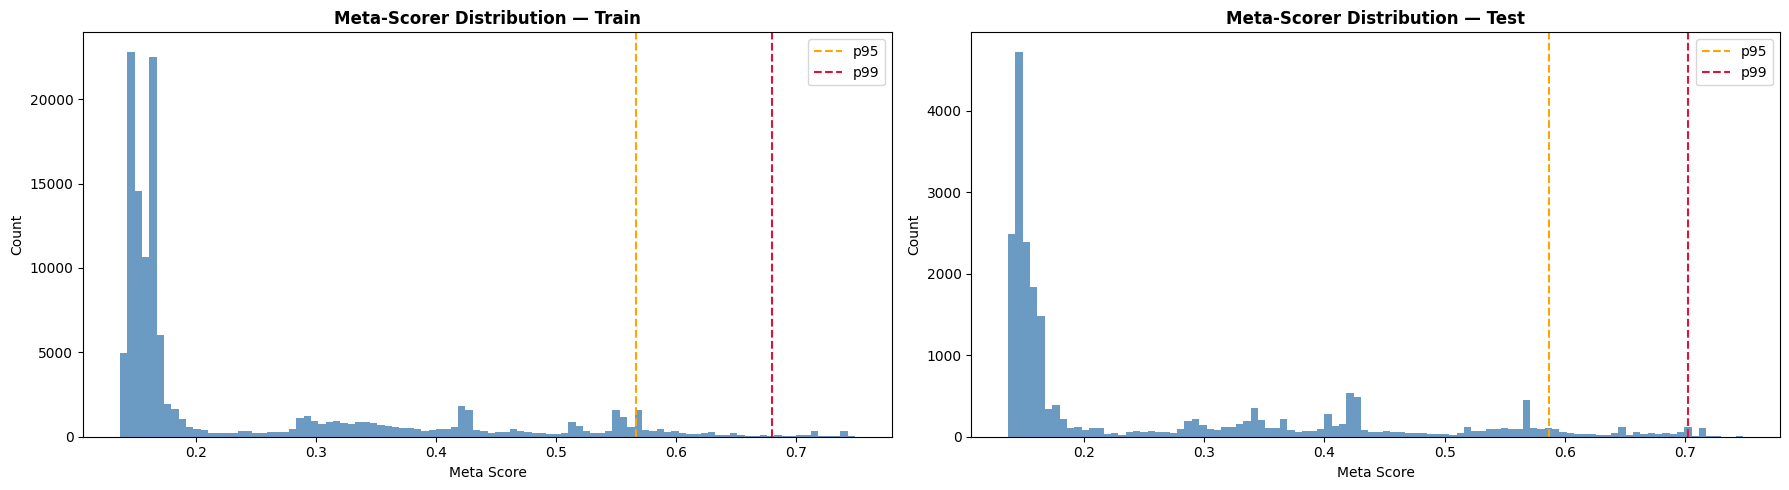

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

# If legitimate: smooth gradient from 0 to 1 with bulk near 0
# If overfit: bimodal spike at 0 and 1 with nothing in between

fig, axes=plt.subplots(1, 2, figsize=(18, 5))

for ax, (name, scores) in zip(axes, [
    ('Train',   meta_scores_train),
    ('Test',    meta_scores_test)
]):
    ax.hist(scores, bins=100, color='steelblue',edgecolor='none', alpha=0.8)
    ax.set_title(f'Meta-Scorer Distribution — {name}',fontweight='bold')
    ax.set_xlabel('Meta Score')
    ax.set_ylabel('Count')
    ax.axvline(np.percentile(scores, 95), color='orange',linestyle='--', label='p95')
    ax.axvline(np.percentile(scores, 99), color='crimson',linestyle='--', label='p99')
    ax.legend()

    # Print percentile summary
    print(f"{name} — p50: {np.percentile(scores,50):.4f} | "
          f"p90: {np.percentile(scores,90):.4f} | "
          f"p95: {np.percentile(scores,95):.4f} | "
          f"p99: {np.percentile(scores,99):.4f}")

plt.tight_layout()
plt.savefig(MODELS_DIR / "meta_score_distributions.png", dpi=150, bbox_inches='tight')
plt.show()

## 6.4 - Parallel Ensemble Path: Rank Aggregation 

In [36]:
# Step 1: Convert normalized scores to ranks
from scipy.stats import rankdata

def to_ranks(scores):
    # Ranks normalized to [0,1]
    return rankdata(scores) / len(scores)

rank_dif   = to_ranks(dif_train_n)
rank_vr    = to_ranks(vr_train_n)
rank_vkl   = to_ranks(vkl_train_n)
rank_ocsvm = to_ranks(ocsvm_train_n)

# Step 2: Compute diversity weights
# Weight = how different each detector's scores are from the mean
# Higher diversity = more unique information = higher weight
score_matrix = np.stack([dif_train_n, vr_train_n, vkl_train_n, ocsvm_train_n], axis=1)
mean_score   = score_matrix.mean(axis=1, keepdims=True)
diversity_weights = np.abs(score_matrix - mean_score).mean(axis=0)
diversity_weights = diversity_weights / diversity_weights.sum()

print("Diversity-based weights:")
for name, w in zip(['DIF','VAE_Recon','VAE_KL','OCSVM'],
                    diversity_weights):
    print(f"  {name:<12}: {w:.4f}")

# Step 3: Weighted rank aggregation
rank_matrix   = np.stack([rank_dif, rank_vr,
                           rank_vkl, rank_ocsvm], axis=1)
ensemble_rank = rank_matrix @ diversity_weights

print(f"\nRank ensemble range: "
      f"[{ensemble_rank.min():.4f}, {ensemble_rank.max():.4f}]")

Diversity-based weights:
  DIF         : 0.1624
  VAE_Recon   : 0.2185
  VAE_KL      : 0.2119
  OCSVM       : 0.4073

Rank ensemble range: [0.2054, 0.9973]


Train — p50: 0.4363 | p90: 0.8167 | p95: 0.9024 | p99: 0.9766
Test — p50: 0.4077 | p90: 0.8496 | p95: 0.8987 | p99: 0.9782


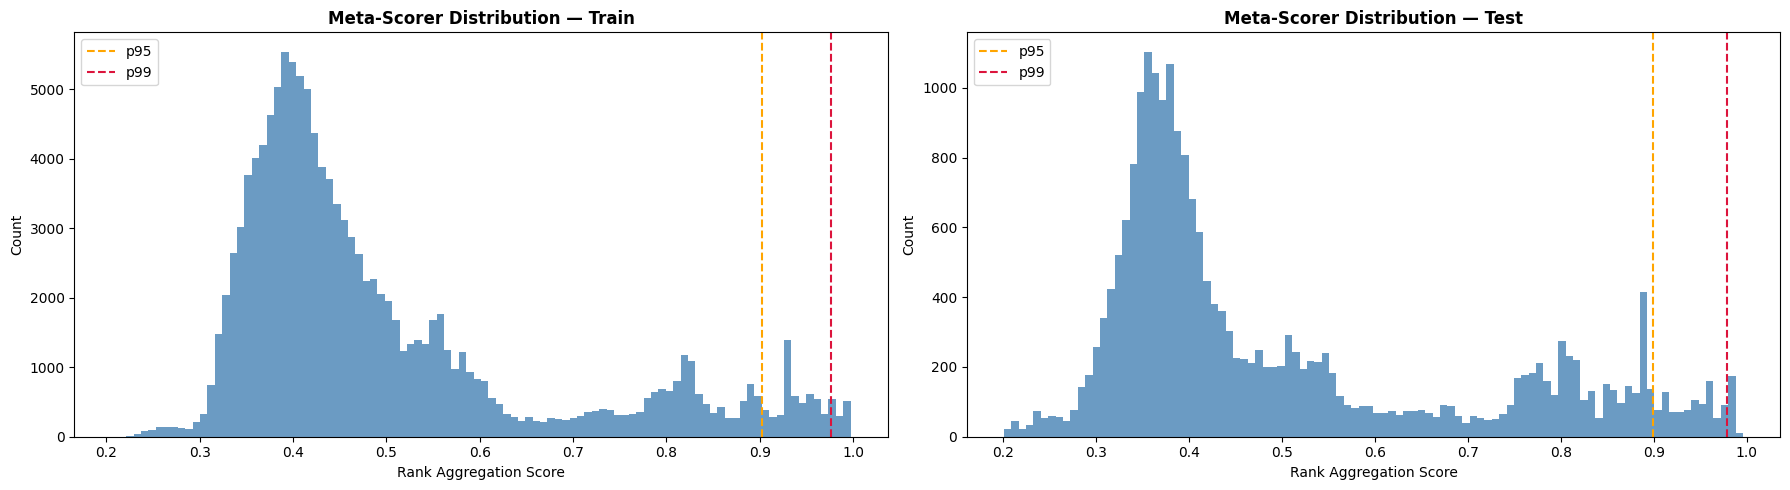

In [40]:
# If legitimate: smooth gradient from 0 to 1 with bulk near 0
# If overfit: bimodal spike at 0 and 1 with nothing in between
rank_matrix_train = np.stack([
    to_ranks(dif_train_n), to_ranks(vr_train_n),
    to_ranks(vkl_train_n), to_ranks(ocsvm_train_n)
], axis=1)

rank_matrix_test = np.stack([
    to_ranks(dif_test_n), to_ranks(vr_test_n),
    to_ranks(vkl_test_n), to_ranks(ocsvm_test_n)
], axis=1)

ensemble_rank_train=rank_matrix_train @ diversity_weights
ensemble_rank_test=rank_matrix_test @ diversity_weights

fig, axes=plt.subplots(1, 2, figsize=(18, 5))

for ax, (name, scores) in zip(axes, [
    ('Train',   ensemble_rank_train),
    ('Test',    ensemble_rank_test)
]):
    ax.hist(scores, bins=100, color='steelblue',edgecolor='none', alpha=0.8)
    ax.set_title(f'Meta-Scorer Distribution — {name}',fontweight='bold')
    ax.set_xlabel('Rank Aggregation Score')
    ax.set_ylabel('Count')
    ax.axvline(np.percentile(scores, 95), color='orange',linestyle='--', label='p95')
    ax.axvline(np.percentile(scores, 99), color='crimson',linestyle='--', label='p99')
    ax.legend()

    # Print percentile summary
    print(f"{name} — p50: {np.percentile(scores,50):.4f} | "
          f"p90: {np.percentile(scores,90):.4f} | "
          f"p95: {np.percentile(scores,95):.4f} | "
          f"p99: {np.percentile(scores,99):.4f}")

plt.tight_layout()
plt.savefig(MODELS_DIR / "rank_aggregation_distributions.png", dpi=150, bbox_inches='tight')
plt.show()

# Stage 7 - Thresholding

## 7.1 - Clean Loading


In [42]:
ensemble_artifacts['rank_train']  = ensemble_rank_train
ensemble_artifacts['rank_test']   = ensemble_rank_test
ensemble_artifacts['diversity_weights'] = diversity_weights

joblib.dump(ensemble_artifacts, MODELS_DIR / "ensemble_artifacts.joblib")
print("Rank ensemble scores saved.")

Rank ensemble scores saved.


In [44]:
ensemble_artifacts=joblib.load(MODELS_DIR / "ensemble_artifacts.joblib")

ensemble_rank_train=ensemble_artifacts['rank_train']
ensemble_rank_test=ensemble_artifacts['rank_test']
train_labels=pd.read_csv(PROCESSED_DIR / "train_labels.csv")
test_labels=pd.read_csv(PROCESSED_DIR / "test_labels.csv")

# Binarization of everything
def binarize_labels(label_series):
    return (label_series.str.strip().str.lower() != 'normal').astype(int).values

y_train=binarize_labels(train_labels['label'])
y_test=binarize_labels(test_labels['label'])

print(f"Train  — Normal: {(y_train==0).sum()} | Attack: {(y_train==1).sum()}")
print(f"Test   — Normal: {(y_test==0).sum()}  | Attack: {(y_test==1).sum()}")

FileNotFoundError: [Errno 2] No such file or directory: '..\\data\\processed\\test_labels.csv'